In [201]:
import pandas as pd
import numpy as np
from scipy.stats import loguniform, randint, uniform
import pickle
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    root_mean_squared_error,
    mean_squared_error
)

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

In [202]:
df = pd.read_csv("src/data/training/raw/merged_training_data.csv")

In [203]:
df['mix__sd_od_history_to_kyc_ratio'] = df['od__history_length_days'] / df['sd__age_since_first_kyc']

In [204]:
ordinal_features = [
    "cb__worst_score",
    "sd__membership_product"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__worst_score
        ["PERSONAL_FLEX", "PERSONAL_STANDARD", "PERSONAL_SMART"
         , "PERSONAL_YOU", "PERSONAL_METAL", "BUSINESS_STANDARD"
         , "BUSINESS_SMART", "BUSINESS_YOU", "BUSINESS_METAL", np.nan]        # sd__membership_product
    ],
    encoded_missing_value=np.nan
)

df[ordinal_features] = ordinal_encoder.fit_transform(
    df[ordinal_features]
)

In [205]:
reg_feats = [
    'ob__open_limit_ref',
 'ob__avg_util_3m',
 'ob__od_enabled_zero_util_days_6m',
 'sd__age',
 'cb__worst_score',
 'ob__max_util_change_3m',
 'ab__inflow_spike_count_6m',
 'ul__is_expat',
 'ab__avg_bal_3m',
 'ob__max_util_3m',
 'sd__max_daily_logins_6m',
 'ab__days_down_6m',
 'ob__max_to_avg_util_3m_ratio',
 'ab__std_util_3m',
 'ob__std_util_3m']

In [206]:
y_reg = df['t__ccf']

X = df.copy()

In [207]:
dates = pd.to_datetime(X["reference_date"])

half = np.where(dates.dt.month <= 6, "H1", "H2")
X["half_year_group"] = dates.dt.year.astype(str) + "-" + half

In [208]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42, stratify=X["half_year_group"])

In [209]:
X_train_reg = X_train[reg_feats]
X_test_reg = X_test[reg_feats]

In [210]:
reg_xgb = XGBRegressor(
    eval_metric='rmse',
    random_state=42,
    n_estimators=1000
)

In [211]:
param_dist = {
    # Objective & Quantile parameters
    "objective": ["reg:squarederror"],
    
    "max_depth": randint(3, 11),
    "min_child_weight": randint(1, 20),
    "gamma": uniform(0.0, 0.5),

    "subsample": uniform(0.2, 0.6),
    "colsample_bytree": uniform(0.5, 0.5),

    "reg_alpha": loguniform(1e-3, 10.0),
    "reg_lambda": loguniform(1e-3, 10.0),
    "learning_rate": loguniform(0.001, 0.3),
    "max_delta_step": randint(0, 5),
}

In [212]:
random_search_reg = RandomizedSearchCV(
    estimator=reg_xgb,
    param_distributions=param_dist,
    n_iter=500,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train_reg, y_train_reg)

print("Best MSE for Regression:", -random_search_reg.best_score_)
print("Best Params for Regression:", random_search_reg.best_params_)
best_reg_model = random_search_reg.best_estimator_

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END colsample_bytree=0.6872700594236812, gamma=0.4753571532049581, learning_rate=0.06504856968981275, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.4755493351795203; total time=   0.8s
[CV] END colsample_bytree=0.6872700594236812, gamma=0.4753571532049581, learning_rate=0.06504856968981275, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.4755493351795203; total time=   0.7s
[CV] END colsample_bytree=0.6872700594236812, gamma=0.4753571532049581, learning_rate=0.06504856968981275, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.4755493351795203; total time=   0.8s
[CV] END colsample_bytree=0.68727005942

In [213]:
with open("xgb_reg_ccf.pkl", "wb") as f:
    pickle.dump(best_reg_model, f)

In [115]:
with open("xgb_reg_ccf.pkl", "rb") as f:
    best_reg_model = pickle.load(f)

In [213]:
best_reg_model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': np.float64(0.8308888662358193),
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'rmse',
 'feature_types': None,
 'feature_weights': None,
 'gamma': np.float64(0.038401524157210765),
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': np.float64(0.007560511785136292),
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': 3,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 16,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': np.float64(0.001538662537264478),
 'reg_lambda': np.float64(0.0189936408272527),
 'sampling_method': None,
 'scale_pos_weight': None,

In [214]:
y_pred_reg = best_reg_model.predict(X_test_reg)

In [215]:
y_pred_reg

array([0.33793184, 0.3430833 , 0.49614152, ..., 0.6792324 , 0.35750508,
       0.8026579 ], shape=(3043,), dtype=float32)

In [216]:
X_test['p__ccf'] = best_reg_model.predict(X_test_reg)

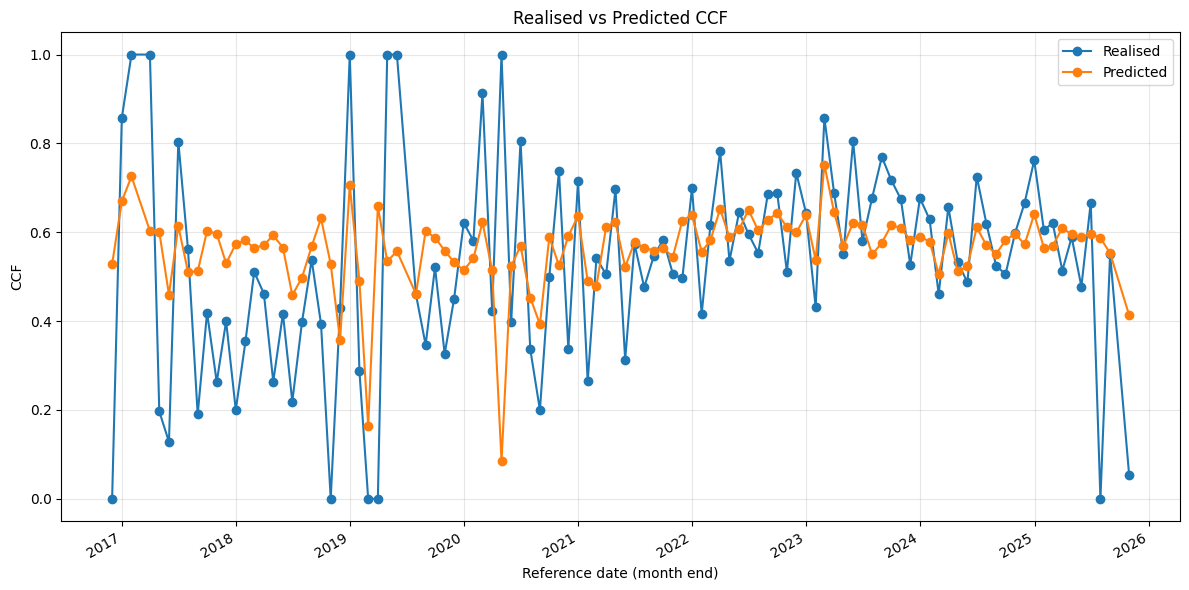

In [217]:
plot_df = X_test.copy()
plot_df["reference_date"] = pd.to_datetime(plot_df["reference_date"])
plot_df["month_end"] = plot_df["reference_date"] + pd.offsets.MonthEnd(0)

# Average values if there are multiple records in the same month.
plot_df = (
    plot_df.groupby("month_end", as_index=False)[["t__ccf", "p__ccf"]]
    .mean()
    .sort_values("month_end")
)

ax = plot_df.plot(
    x="month_end",
    y=["t__ccf", "p__ccf"],
    kind="line",
    marker="o",
    figsize=(12, 6),
)

ax.set(
    title="Realised vs Predicted CCF",
    xlabel="Reference date (month end)",
    ylabel="CCF",
)
ax.legend(["Realised", "Predicted"])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [170]:
significance_analysis_df = X_test[['reference_date', 't__ccf', 'p__ccf']].copy()

In [171]:
from scipy import stats


def evaluate_monthly_underestimation(
    df: pd.DataFrame,
    date_col: str = "reference_date",
    actual_col: str = "t__ccf",
    pred_col: str = "p__ccf",
    start_date: str = "2021-01-01",
    alpha: float = 0.05,
) -> pd.DataFrame:
    """Aggregates data to monthly averages matching the plot pipeline and evaluates post-2021 underestimation.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing reference_date, actual target (t__ccf), and predictions (p__ccf).
    date_col : str
        Column name for reference dates.
    actual_col : str
        Realised CCF column name ('t__ccf').
    pred_col : str
        Predicted CCF column name ('p__ccf').
    start_date : str
        Cutoff date for post-period assessment (default: '2021-01-01').
    alpha : float
        Significance threshold (default = 0.05).
    """
    # 1. Match your exact aggregation pipeline
    plot_df = df.copy()
    plot_df[date_col] = pd.to_datetime(plot_df[date_col])
    plot_df["month_end"] = plot_df[date_col] + pd.offsets.MonthEnd(0)

    # Average values per month end
    plot_df = (
        plot_df.groupby("month_end", as_index=False)[[actual_col, pred_col]]
        .mean()
        .sort_values("month_end")
    )

    # Calculate monthly residual: Positive residual = Realised > Predicted (Underestimation)
    plot_df["monthly_residual"] = plot_df[actual_col] - plot_df[pred_col]

    # 2. Split into Pre and Post sub-periods
    df_post = plot_df[plot_df["month_end"] >= start_date].dropna(
        subset=["monthly_residual"]
    )
    df_pre = plot_df[plot_df["month_end"] < start_date].dropna(
        subset=["monthly_residual"]
    )

    post_residuals = df_post["monthly_residual"]
    n_months = len(post_residuals)

    if n_months == 0:
        raise ValueError(f"No monthly data found on or after {start_date}")

    # 3. Monthly Metrics
    mean_err = post_residuals.mean()
    rmse = np.sqrt((post_residuals**2).mean())
    underest_count = (post_residuals > 0).sum()
    underest_rate = underest_count / n_months

    # 4. Statistical Hypothesis Tests (H0: Mean Monthly Error <= 0 vs H1: Error > 0)
    # Parametric t-test on monthly averages
    t_stat, p_val_t = stats.ttest_1samp(
        post_residuals, 0, alternative="greater"
    )

    # Non-parametric Wilcoxon test
    try:
        w_stat, p_val_w = stats.wilcoxon(
            post_residuals, zero_method="pratt", alternative="greater"
        )
    except Exception:
        w_stat, p_val_w = np.nan, np.nan

    # Binomial test on underestimated months count vs 50%
    binom_res = stats.binomtest(
        underest_count, n_months, p=0.5, alternative="greater"
    )
    p_val_b = binom_res.pvalue

    # 5. Pre vs Post Structural Shift (Welch's t-test)
    welch_t_stat, p_val_welch = np.nan, np.nan
    pre_mean = np.nan
    if len(df_pre) > 0:
        pre_mean = df_pre["monthly_residual"].mean()
        welch_t_stat, p_val_welch = stats.ttest_ind(
            df_post["monthly_residual"],
            df_pre["monthly_residual"],
            equal_var=False,
            alternative="greater",
        )

    # 6. Formatted Report
    print("=" * 68)
    print(
        f"MONTHLY AGGREGATED UNDERESTIMATION REPORT (Post-{start_date[:4]}, N = {n_months} months)"
    )
    print("=" * 68)
    print(f"Mean Monthly Residual (t__ccf - p__ccf) : {mean_err:+.4f}")
    print(f"Monthly RMSE                            : {rmse:.4f}")
    print(
        f"Underestimated Months                   : {underest_count}/{n_months} ({underest_rate:.1%})"
    )
    print("-" * 68)
    print(
        "HYPOTHESIS TESTS (H0: Mean Monthly Error <= 0 vs H1: Error > 0)"
    )
    print("-" * 68)
    print(
        f"1. One-sample t-test          : t = {t_stat:6.3f} | p-value = {p_val_t:.4f} {'*' if p_val_t < alpha else ''}"
    )
    print(
        f"2. Wilcoxon Signed-Rank Test   : W = {w_stat:6.3f} | p-value = {p_val_w:.4f} {'*' if p_val_w < alpha else ''}"
    )
    print(
        f"3. Binomial Sign Test         : k = {underest_count:2d}/{n_months}  | p-value = {p_val_b:.4f} {'*' if p_val_b < alpha else ''}"
    )

    if len(df_pre) > 0:
        print("-" * 68)
        print("STRUCTURAL SHIFT ANALYSIS (Pre vs Post 2021)")
        print("-" * 68)
        print(f"Pre-2021 Mean Monthly Residual : {pre_mean:+.4f}")
        print(
            f"Welch's Two-Sample t-test     : t = {welch_t_stat:6.3f} | p-value = {p_val_welch:.4f} {'*' if p_val_welch < alpha else ''}"
        )

    print("=" * 68)
    signif = (
        p_val_t < alpha
        or (not np.isnan(p_val_w) and p_val_w < alpha)
        or p_val_b < alpha
    )
    if signif:
        print(
            f"VERDICT: Significant monthly underestimation detected at alpha = {alpha}."
        )
    else:
        print(
            f"VERDICT: Insufficient evidence of monthly underestimation at alpha = {alpha}."
        )
    print("=" * 68)

    return plot_df

In [174]:
# Assuming your DataFrame is named 'df' with columns 'reference_date', 'Realised', 'Predicted'
significance_analysis_df["reference_date"] = pd.to_datetime(significance_analysis_df["reference_date"])

# Execute the test
df_with_residuals = evaluate_monthly_underestimation(
    df=significance_analysis_df,
    date_col="reference_date",
    actual_col="t__ccf",
    pred_col="p__ccf",
    start_date="2021-01-01",
)

MONTHLY AGGREGATED UNDERESTIMATION REPORT (Post-2021, N = 57 months)
Mean Monthly Residual (t__ccf - p__ccf) : -0.0095
Monthly RMSE                            : 0.1275
Underestimated Months                   : 30/57 (52.6%)
--------------------------------------------------------------------
HYPOTHESIS TESTS (H0: Mean Monthly Error <= 0 vs H1: Error > 0)
--------------------------------------------------------------------
1. One-sample t-test          : t = -0.560 | p-value = 0.7112 
2. Wilcoxon Signed-Rank Test   : W = 867.000 | p-value = 0.3738 
3. Binomial Sign Test         : k = 30/57  | p-value = 0.3957 
--------------------------------------------------------------------
STRUCTURAL SHIFT ANALYSIS (Pre vs Post 2021)
--------------------------------------------------------------------
Pre-2021 Mean Monthly Residual : -0.0602
Welch's Two-Sample t-test     : t =  1.113 | p-value = 0.1350 
VERDICT: Insufficient evidence of monthly underestimation at alpha = 0.05.


In [107]:
y_pred_reg = best_reg_model.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
print("MSE:", mse, "RMSE:", rmse)

MSE: 0.1842606028097183 RMSE: 0.42925587102533413


In [194]:
best_reg_model.fit(X_train_reg, y_train_reg)

explainer = shap.TreeExplainer(best_reg_model)
shap_values = explainer.shap_values(X_train_reg)

top_shap_reg = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_reg.columns)
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

In [195]:
top_shap_reg

['ob__open_limit_ref',
 'ob__avg_util_3m',
 'ob__od_enabled_zero_util_days_6m',
 'sd__age',
 'cb__worst_score',
 'ob__max_util_change_3m',
 'ab__inflow_spike_count_6m',
 'ul__is_expat',
 'ab__avg_bal_3m',
 'ob__max_util_3m',
 'sd__max_daily_logins_6m',
 'ab__days_down_6m',
 'ob__max_to_avg_util_3m_ratio',
 'ab__std_util_3m',
 'ob__std_util_3m']

# Test Set and hurdle model

In [18]:
y_pred_test_reg = best_reg_model.predict(X_test_reg)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test_reg,y_pred_test_reg)
print(f"RMSE: {rmse}")

RMSE: 0.4263778703454898


Calibration by Decile:
   decile  predicted    actual
0       0   0.262751  0.258258
1       1   0.437084  0.426442
2       2   0.502113  0.517709
3       3   0.545071  0.572369
4       4   0.583632  0.605235
5       5   0.622592  0.643677
6       6   0.659470  0.660298
7       7   0.698018  0.729727
8       8   0.749984  0.711750
9       9   0.874116  0.878524

Metrics by Decile:
   decile       mse      rmse  count
0       0  0.156571  0.395690  305.0
1       1  0.206801  0.454754  304.0
2       2  0.219821  0.468851  304.0
3       3  0.209018  0.457185  304.0
4       4  0.203190  0.450765  305.0
5       5  0.196368  0.443134  304.0
6       6  0.184654  0.429714  304.0
7       7  0.168691  0.410720  304.0
8       8  0.178295  0.422250  304.0
9       9  0.094872  0.308012  305.0


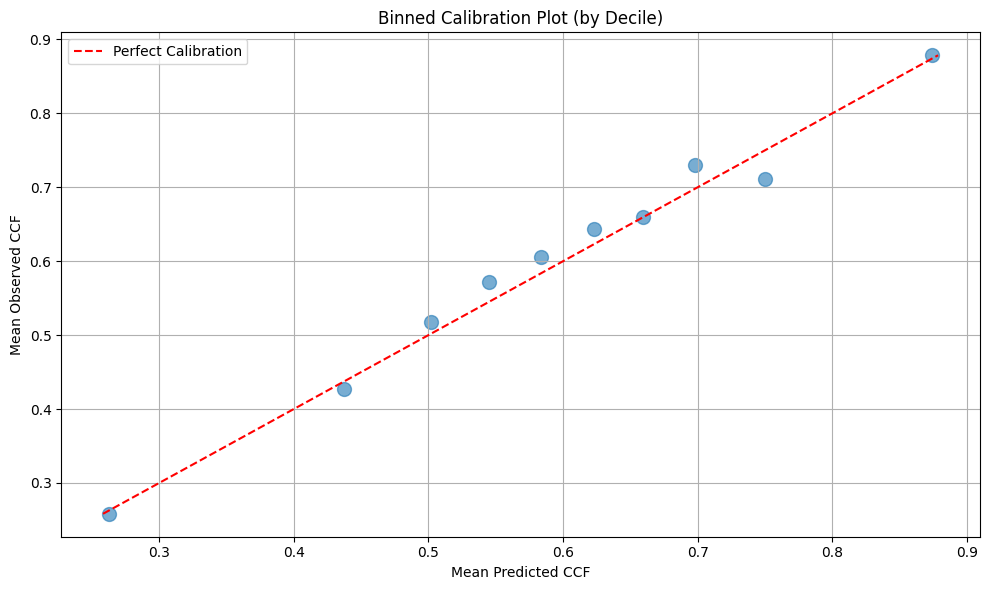

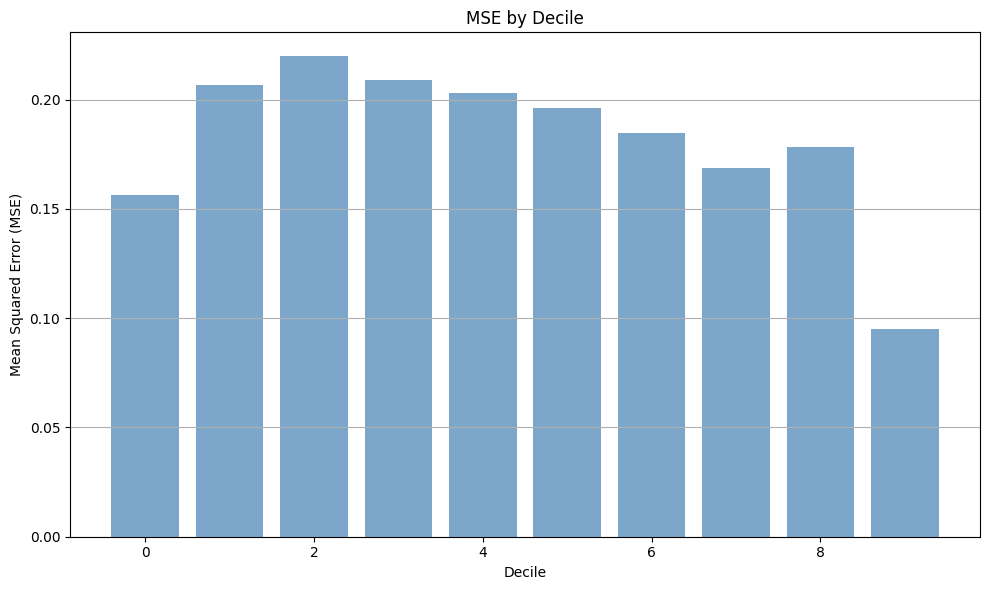

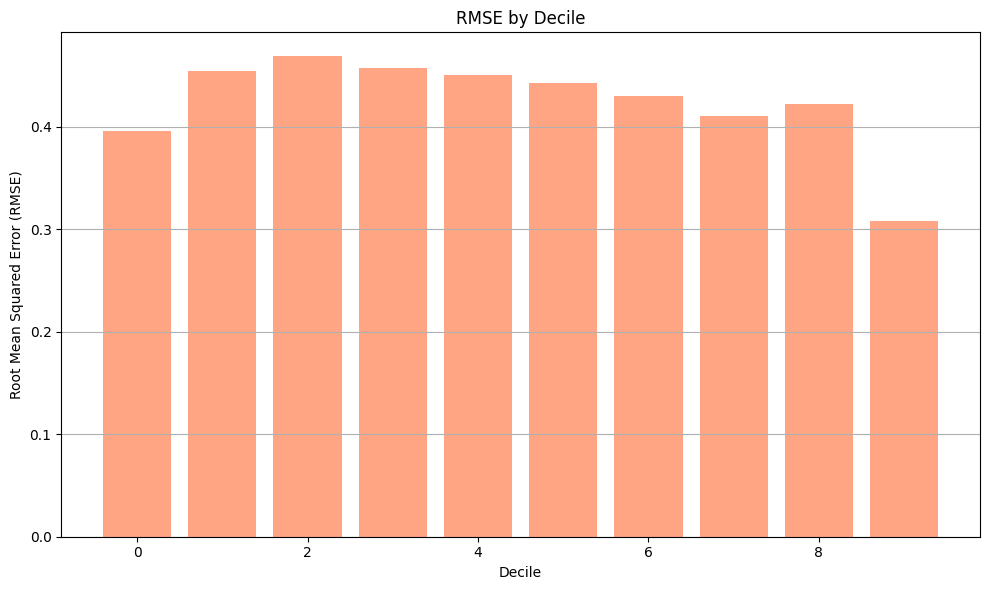

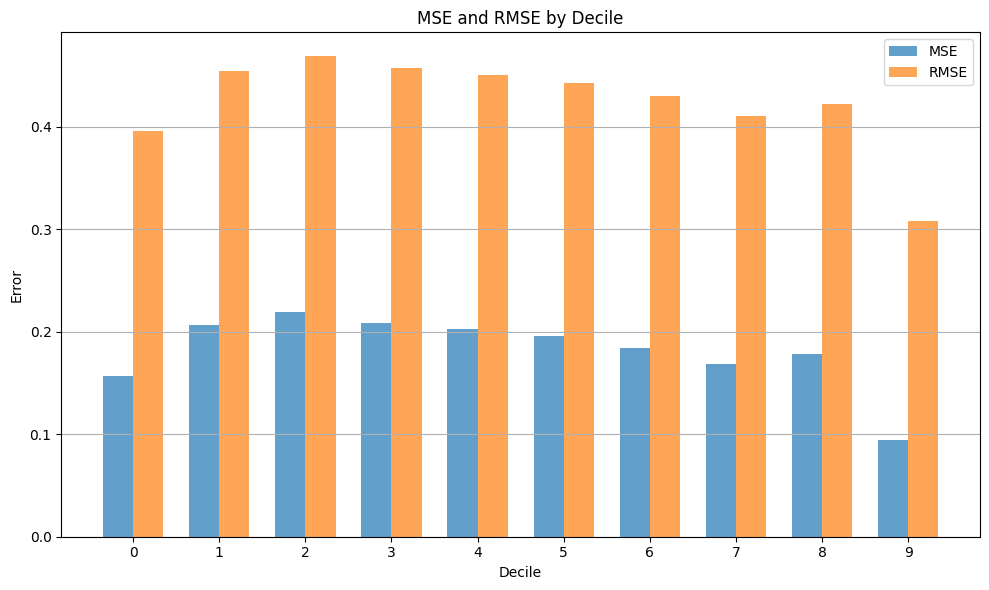

In [20]:
y_test = y_test_reg.copy()
y_pred = y_pred_test_reg.copy()

df_eval = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
})

df_eval['decile'] = pd.qcut(df_eval['predicted'], q=10, labels=False, duplicates='drop')

calibration = df_eval.groupby('decile').agg({
    'predicted': 'mean',
    'actual': 'mean'
}).reset_index()

metrics_by_decile = df_eval.groupby('decile').apply(
    lambda x: pd.Series({
        'mse': mean_squared_error(x['actual'], x['predicted']),
        'rmse': np.sqrt(mean_squared_error(x['actual'], x['predicted'])),
        'count': len(x)
    })
).reset_index()

print("Calibration by Decile:")
print(calibration)
print("\nMetrics by Decile:")
print(metrics_by_decile)

# Plot 1: Binned Calibration Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(calibration['predicted'], calibration['actual'], s=100, alpha=0.6)
# Plot perfect calibration line
min_val = min(calibration['predicted'].min(), calibration['actual'].min())
max_val = max(calibration['predicted'].max(), calibration['actual'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted CCF')
ax.set_ylabel('Mean Observed CCF')
ax.set_title('Binned Calibration Plot (by Decile)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(metrics_by_decile['decile'], metrics_by_decile['mse'], alpha=0.7, color='steelblue')
ax.set_xlabel('Decile')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('MSE by Decile')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(metrics_by_decile['decile'], metrics_by_decile['rmse'], alpha=0.7, color='coral')
ax.set_xlabel('Decile')
ax.set_ylabel('Root Mean Squared Error (RMSE)')
ax.set_title('RMSE by Decile')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_by_decile))
width = 0.35
ax.bar(x - width/2, metrics_by_decile['mse'], width, label='MSE', alpha=0.7)
ax.bar(x + width/2, metrics_by_decile['rmse'], width, label='RMSE', alpha=0.7)
ax.set_xlabel('Decile')
ax.set_ylabel('Error')
ax.set_title('MSE and RMSE by Decile')
ax.set_xticks(x)
ax.set_xticklabels(metrics_by_decile['decile'])
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

 99%|===================| 3020/3043 [00:55<00:00]        

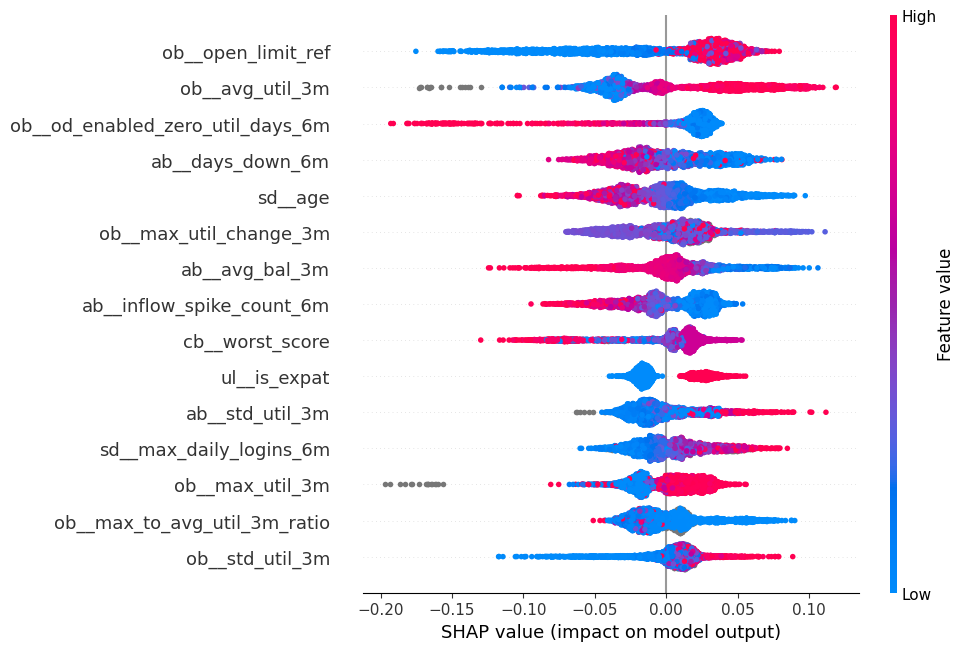

In [21]:
explainer = shap.Explainer(best_reg_model, X_test_reg)
shap_values = explainer(X_test_reg)

shap.plots.beeswarm(shap_values, max_display=30)